
# Predicción de victorias/derrotas con métricas ROLL10

En este cuaderno construiremos un flujo completo y fácilmente extensible para predecir si el equipo local ganará o perderá un partido (`W/L`). El objetivo es mantener un **pipeline didáctico**, apoyándonos en las métricas rodantes de los últimos 10 encuentros (`ROLL10_…`) y transformándolas a un **dataset a nivel de partido (home vs away)** con características relativas.

Los pasos principales incluyen: (1) recalcular las medias rodantes sin fuga temporal mediante `shift(1)`, (2) generar el dataset home/away con variables diferenciales entre ambos equipos y (3) entrenar un modelo **XGBoost** con *early stopping*. Además, seleccionaremos el umbral óptimo en validación con el criterio de **Youden**, representaremos las métricas clave y exportaremos las predicciones para su análisis posterior.



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')




## Configuración principal

La celda siguiente concentra todas las opciones importantes del flujo: rutas de entrada/salida, ventana rolling, lista de métricas base y parámetros de muestreo. Modificando este bloque se pueden probar nuevas combinaciones de características, activar fuentes externas o ajustar la semilla de aleatoriedad.



In [2]:

# === CONFIGURACIÓN PRINCIPAL ===
DATA_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet"
OUTPUT_DIR = "/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds"
ROLLING_WINDOW = 10
BASE_FEATURES = [
    'NET_RATING','E_NET_RATING','DEF_RATING','E_DEF_RATING',
    'PTS','FGM','FG_PCT','EFG_PCT','TS_PCT',
    'TOV','TM_TOV_PCT','OREB_PCT','DREB','POSS',
    'PACE','PCT_FGA_2PT','PCT_FGA_3PT','PCT_PTS_FT'
]
RELATIVE_PREFIXES = ("ROLL10_",)
TEST_SIZE = 0.20
VAL_SIZE = 0.10
RANDOM_STATE = 42

# === OPCIONAL: Parquets externos ===
# ExternalFeaturesConfig = [
#     {
#         "path": "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_dash_pt_pass__dataset_0.parquet",
#         "on": ["TEAM_ID","GAME_DATE"],
#         "select": ["AST_PCT","PCT_AST_2PM","PCT_AST_3PM"],
#         "prefix": "PASS_"
#     }
# ]
ExternalFeaturesConfig = []




## Carga y limpieza de datos

Cargamos el parquet indicado en la configuración y nos aseguramos de que las columnas fundamentales estén presentes. Convertimos `GAME_DATE` a formato `datetime`, generamos `WL_NUM` si solo contamos con la etiqueta textual y dejamos únicamente identificadores más las métricas base que alimentarán el cálculo rolling y las diferencias home/away.



In [3]:
df = pd.read_parquet(DATA_PATH)
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

# Asegura columna binaria del resultado
if 'WL_NUM' not in df.columns and 'WL' in df.columns:
    df['WL_NUM'] = df['WL'].map({'W': 1, 'L': 0})
elif 'WL' not in df.columns and 'WL_NUM' in df.columns:
    df['WL'] = df['WL_NUM'].map({1: 'W', 0: 'L'})

# --- columnas base mínimas necesarias ---
id_columns = ['TEAM_ID', 'TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'WL_NUM']

# === NO recalcular rolling ===
# En lugar de BASE_FEATURES, seleccionamos las columnas ya laggeadas ROLL10_
roll_features = sorted([c for c in df.columns if c.startswith('ROLL10_')])

# --- avisos y selección ---
if not roll_features:
    print("⚠️ No se encontraron columnas ROLL10_ en el parquet.")
else:
    print(f"Columnas ROLL10 detectadas: {len(roll_features)}")

selected_columns = [c for c in id_columns if c in df.columns] + roll_features
df = df[selected_columns].copy()

print(f"Filas totales: {len(df)}")
print(f"Fechas: {df['GAME_DATE'].min().date()} → {df['GAME_DATE'].max().date()}")
print(f"Equipos únicos: {df['TEAM_ID'].nunique()}")
df.head(3)


Columnas ROLL10 detectadas: 75
Filas totales: 2639
Fechas: 2024-07-06 → 2025-04-13
Equipos únicos: 30


,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,WL,WL_NUM,ROLL10_AST,ROLL10_AST_PCT,ROLL10_AST_TOV,...,ROLL10_PTS_FB,ROLL10_PTS_OFF_TOV,ROLL10_PTS_PAINT,ROLL10_REB,ROLL10_REB_PCT,ROLL10_STL,ROLL10_TM_TOV_PCT,ROLL10_TOV,ROLL10_TS_PCT,ROLL10_USG_PCT
0,1610612737,ATL,0022400001,2024-11-12,ATL @ BOS,W,1,28.3,0.153264,1.054945,...,1.570403,1.971515,5.510302,42.3,0.079349,9.9,9.890706,15.6,0.588391,0.182248
1,1610612738,BOS,0022400001,2024-11-12,BOS vs. ATL,L,0,23.0,0.125570,1.071138,...,1.594227,1.796850,4.023699,43.8,0.083278,8.1,9.642725,12.7,0.496815,0.171726
2,1610612748,MIA,0022400002,2024-11-12,MIA @ DET,L,0,25.6,0.151024,1.407589,...,1.473386,1.711322,4.049762,42.1,0.088033,9.2,9.128242,13.5,0.524954,0.182251



## Añadir features externas (opcional)

Si deseamos enriquecer el dataset con variables adicionales, podemos utilizar la estructura `ExternalFeaturesConfig`. Cada elemento define la ruta del parquet, las claves de unión, las columnas que queremos incorporar y un prefijo para renombrarlas. El siguiente ejemplo permanece comentado para mantener el flujo base ligero, pero sirve como plantilla para añadir más información cuando sea necesario.



In [4]:

# def add_external_features(df, cfg):
#     ext = pd.read_parquet(cfg["path"])
#     ext = ext[cfg["on"] + cfg["select"]]
#     new_cols = [cfg["prefix"] + c for c in cfg["select"]]
#     ext.columns = cfg["on"] + new_cols
#     return df.merge(ext, on=cfg["on"], how="left")

# for cfg in ExternalFeaturesConfig:
#     df = add_external_features(df, cfg)
# print("Datos extendidos con features externas (si las hubiera).")




## Cálculo de métricas rolling sin fuga

Ordenamos por equipo y fecha, aplicando `shift(1)` antes de la media móvil para evitar fuga temporal. De este modo cada fila solo utiliza información de partidos anteriores al actual.



In [5]:
# --- BLOQUE CORREGIDO: solo usa las columnas ROLL10_ ya existentes ---
df = df.sort_values(['TEAM_ID', 'GAME_DATE'])

# Detecta automáticamente todas las columnas ROLL10_ que ya vienen en el parquet
roll_cols = sorted([c for c in df.columns if c.startswith('ROLL10_')])

if not roll_cols:
    print("⚠️ No se encontraron columnas ROLL10_ en el parquet. Verifica el archivo de entrada.")
else:
    print(f"Columnas ROLL10 detectadas: {len(roll_cols)}")

# No se recalculan rolling ni se crean nuevas columnas
# (ya están correctamente calculadas y desplazadas en el parquet original)


Columnas ROLL10 detectadas: 75



## Imputación de valores nulos

Completamos los `NaN` de las métricas rolling utilizando la mediana de cada columna. Esto garantiza que la construcción posterior del dataset home/away no propague valores faltantes al calcular diferencias.



In [6]:
# --- BLOQUE CORREGIDO: imputación segura de columnas ROLL10_ ---
roll_cols = sorted([c for c in df.columns if c.startswith('ROLL10_')])

if not roll_cols:
    print("⚠️ No hay columnas ROLL10_ para imputar valores faltantes.")
else:
    for col in roll_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    print(f"Columnas ROLL10 imputadas (con la mediana): {len(roll_cols)}")


Columnas ROLL10 imputadas (con la mediana): 75



## Construcción del dataset local vs visitante

Transformamos el registro por equipo en un dataset a nivel de partido. Identificamos al equipo local a partir de `MATCHUP`, separamos locales y visitantes y, tras cruzarlos por `GAME_ID`, generamos características diferenciales (`HOME_x - AWAY_x`). El objetivo (`y`) se define desde la perspectiva local.



In [7]:
# --- BLOQUE CORREGIDO: build_match_level sin fuga (solo ROLL10_) ---
def build_match_level(df, numeric_feature_prefixes=("ROLL10_",)):
    d = df.copy()

    # Local/visitante desde MATCHUP (ajusta si tu formato difiere)
    d['IS_HOME'] = d['MATCHUP'].astype(str).str.contains('vs', case=False).astype(int)

    # Separamos y añadimos prefijos
    home = d[d['IS_HOME'] == 1].copy().add_prefix('HOME_')
    away = d[d['IS_HOME'] == 0].copy().add_prefix('AWAY_')

    # Unimos por GAME_ID (ya con prefijos)
    merged = pd.merge(
        home, away,
        left_on='HOME_GAME_ID', right_on='AWAY_GAME_ID',
        how='inner'
    )

    # Etiqueta: ganó el HOME
    merged['y'] = (merged['HOME_WL'].astype(str).str.upper().str.strip() == 'W').astype(int)

    # --- SOLO columnas con lag: ROLL10_ ---
    # 1) Construimos el conjunto base (sin duplicados) a partir de columnas numéricas
    bases = []
    for col in merged.columns:
        if not (col.startswith('HOME_') or col.startswith('AWAY_')):
            continue
        base = col.replace('HOME_', '').replace('AWAY_', '')
        # Solo aceptamos columnas que empiecen por ROLL10_ y que sean numéricas
        if base.startswith(numeric_feature_prefixes) and merged[col].dtype.kind in 'if':
            bases.append(base)

    bases = sorted(set(bases))  # p.ej. ['ROLL10_NET_RATING', 'ROLL10_TS_PCT', ...]

    # 2) Construimos features relativas: HOME - AWAY
    X_rel = pd.DataFrame(index=merged.index)
    for base in bases:
        h, a = f'HOME_{base}', f'AWAY_{base}'
        if h in merged.columns and a in merged.columns:
            X_rel[f'DIFF_{base}'] = merged[h] - merged[a]

    # Señal simple de factor cancha (constante 1 porque todas las filas son HOME vs AWAY)
    X_rel['HOME_COURT'] = 1

    # Objetivo
    y = merged['y'].values

    # Metadatos útiles para análisis
    aux_cols = ['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'HOME_GAME_DATE']
    aux_cols = [c for c in aux_cols if c in merged.columns]
    meta = merged[aux_cols].copy()

    # --- Sanity checks contra fuga ---
    # No deben colarse diferencias de columnas "instantáneas" (no ROLL10_)
    assert all(c.startswith('DIFF_ROLL10_') or c == 'HOME_COURT' for c in X_rel.columns), \
        "Se han colado features sin lag. Revisa los prefijos permitidos."

    return X_rel, y, meta

# Construcción de dataset match-level
X_all, y_all, meta_all = build_match_level(df)
print(f"Shape X: {X_all.shape}")
print(f"Tasa de victoria local: {y_all.mean():.3f}")
X_all.head()


Shape X: (1311, 76)
Tasa de victoria local: 0.543


,DIFF_ROLL10_AST,DIFF_ROLL10_AST_PCT,DIFF_ROLL10_AST_TOV,DIFF_ROLL10_BLK,DIFF_ROLL10_BLKA,DIFF_ROLL10_DEF_RATING,DIFF_ROLL10_DREB,DIFF_ROLL10_DREB_PCT,DIFF_ROLL10_EFG_PCT,DIFF_ROLL10_E_DEF_RATING,...,DIFF_ROLL10_PTS_OFF_TOV,DIFF_ROLL10_PTS_PAINT,DIFF_ROLL10_REB,DIFF_ROLL10_REB_PCT,DIFF_ROLL10_STL,DIFF_ROLL10_TM_TOV_PCT,DIFF_ROLL10_TOV,DIFF_ROLL10_TS_PCT,DIFF_ROLL10_USG_PCT,HOME_COURT
0,-0.500000,0.00000,0.00000,3.750000,2.000000,0.00000,5.000000,0.00000,0.00000,0.00000,...,0.00000,0.0,-4.00,0.00000,3.750000,0.00000,-1.000000,0.0000,0.00000,1
1,-2.800000,0.00000,0.00000,1.200000,-0.400000,0.00000,3.500000,0.00000,0.00000,0.00000,...,0.00000,0.0,1.90,0.00000,1.300000,0.00000,1.400000,0.0000,0.00000,1
2,-2.250000,0.00000,0.00000,3.250000,1.250000,0.00000,1.500000,0.00000,0.00000,0.00000,...,0.00000,0.0,5.25,0.00000,0.750000,0.00000,3.250000,0.0000,0.00000,1
3,-0.600000,0.00000,0.00000,1.000000,1.600000,0.00000,4.600000,0.00000,0.00000,0.00000,...,0.00000,0.0,6.20,0.00000,-2.400000,0.00000,2.600000,0.0000,0.00000,1
4,0.111111,0.02026,0.10289,-0.166667,0.833333,5.61444,-1.666667,0.00354,0.00186,5.61444,...,1.08889,1.8,-2.00,-0.00736,0.833333,-1.55889,3.944444,0.0437,-0.00216,1



## Entrenamiento con XGBoost y validación temporal

Dividimos el dataset en conjuntos de entrenamiento y prueba (80/20) estratificados, reservando además un 10 % del entrenamiento como validación para *early stopping*. Ajustamos un `XGBClassifier` conservador y calculamos el umbral óptimo (Youden) en la validación antes de generar predicciones finales sobre el test.



In [8]:
# --- split (igual que el tuyo) ---
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_all, y_all, meta_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

# --- crea el modelo intentando early_stopping en el CONSTRUCTOR ---
common_kwargs = dict(
    n_estimators=1200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

try:
    # XGBoost que soporta early_stopping_rounds en __init__
    xgb = XGBClassifier(early_stopping_rounds=75, **common_kwargs)
except TypeError:
    # Versión sin ese parámetro en __init__
    xgb = XGBClassifier(**common_kwargs)

# --- fit: NADA de early_stopping en .fit (para evitar tu error) ---
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

# Si la versión tiene best_iteration_, úsalo para predecir con los mejores árboles
use_ntree_limit = {}
if hasattr(xgb, "best_iteration_") and xgb.best_iteration_ is not None:
    use_ntree_limit = {"iteration_range": (0, xgb.best_iteration_ + 1)}

# --- probabilidades ---
proba_val  = xgb.predict_proba(X_val,  **use_ntree_limit)[:, 1]
proba_test = xgb.predict_proba(X_test, **use_ntree_limit)[:, 1]

# --- umbral óptimo (Youden) ---
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, proba_val)
youden_scores = tpr_val - fpr_val
best_idx = int(np.argmax(youden_scores))
best_thresh = float(thresholds_val[best_idx]) if np.isfinite(thresholds_val[best_idx]) else 0.5

y_pred = (proba_test >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(f"Partidos Train/Test: {len(X_train)} / {len(X_test)}")
print(f"Victorias locales en train: {y_train.mean():.3f}")
print(f"Umbral óptimo (Youden): {best_thresh:.4f}")


Partidos Train/Test: 1048 / 263
Victorias locales en train: 0.543
Umbral óptimo (Youden): 0.4856



## Evaluación con métricas clasificatorias

Calculamos las métricas principales sobre el conjunto de test utilizando el umbral de Youden obtenido en validación: exactitud, exactitud balanceada, AUC-ROC, Average Precision, Brier Score y Log Loss. También registramos el propio umbral para referencia.



In [9]:

metrics = {
    'accuracy': float((y_pred == y_test).mean()),
    'roc_auc': float(roc_auc_score(y_test, proba_test)),
    'avg_precision': float(average_precision_score(y_test, proba_test)),
    'brier': float(brier_score_loss(y_test, proba_test)),
    'log_loss': float(log_loss(y_test, proba_test)),
    'best_threshold': float(best_thresh)
}

pos_mask = y_test == 1
neg_mask = y_test == 0
sens = (y_pred[pos_mask] == 1).mean() if pos_mask.any() else np.nan
spec = (y_pred[neg_mask] == 0).mean() if neg_mask.any() else np.nan
metrics['balanced_acc'] = float(np.nanmean([sens, spec]))

metrics_df = pd.Series(metrics, name='XGBoost (Youden)').to_frame().T
metrics_df



,accuracy,roc_auc,avg_precision,brier,log_loss,best_threshold,balanced_acc
XGBoost (Youden),0.669202,0.703089,0.708626,0.215493,0.620846,0.485611,0.656935



## Importancia de características

Inspeccionamos rápidamente las diferencias más relevantes según la importancia de atributos calculada por XGBoost para orientar futuros análisis.



In [10]:

feature_importance = pd.Series(xgb.feature_importances_, index=X_all.columns).sort_values(ascending=False)
feature_importance.head(25)



DIFF_ROLL10_PLUS_MINUS            0.038808
DIFF_ROLL10_E_NET_RATING          0.022997
DIFF_ROLL10_OPP_PTS_OFF_TOV       0.019002
DIFF_ROLL10_PTS                   0.017900
DIFF_ROLL10_NET_RATING            0.017813
DIFF_ROLL10_PCT_AST_3PM           0.016907
DIFF_ROLL10_USG_PCT               0.016086
DIFF_ROLL10_PCT_FTM               0.015976
DIFF_ROLL10_DEF_RATING            0.015798
DIFF_ROLL10_PTS_PAINT             0.015727
DIFF_ROLL10_FGA                   0.015293
DIFF_ROLL10_OPP_PTS_2ND_CHANCE    0.015192
DIFF_ROLL10_AST                   0.014998
DIFF_ROLL10_PCT_PTS_FB            0.014860
DIFF_ROLL10_PCT_FGM               0.014819
DIFF_ROLL10_PCT_DREB              0.014650
DIFF_ROLL10_OPP_PTS_PAINT         0.014399
DIFF_ROLL10_BLK                   0.014215
DIFF_ROLL10_PCT_FGA_2PT           0.014203
DIFF_ROLL10_PTS_2ND_CHANCE        0.014180
DIFF_ROLL10_FG3_PCT               0.014146
DIFF_ROLL10_PCT_PTS               0.013905
DIFF_ROLL10_PCT_FGA               0.013774
DIFF_ROLL10


## Gráficas principales

Visualizamos tres perspectivas complementarias del rendimiento empleando el modelo XGBoost con el umbral de Youden:

1. **Curva ROC** para analizar el equilibrio entre verdaderos positivos y falsos positivos.
2. **Curva de calibración** para comprobar la calidad probabilística de las predicciones.
3. **Matriz de confusión** para resumir aciertos y errores con el umbral óptimo calculado.



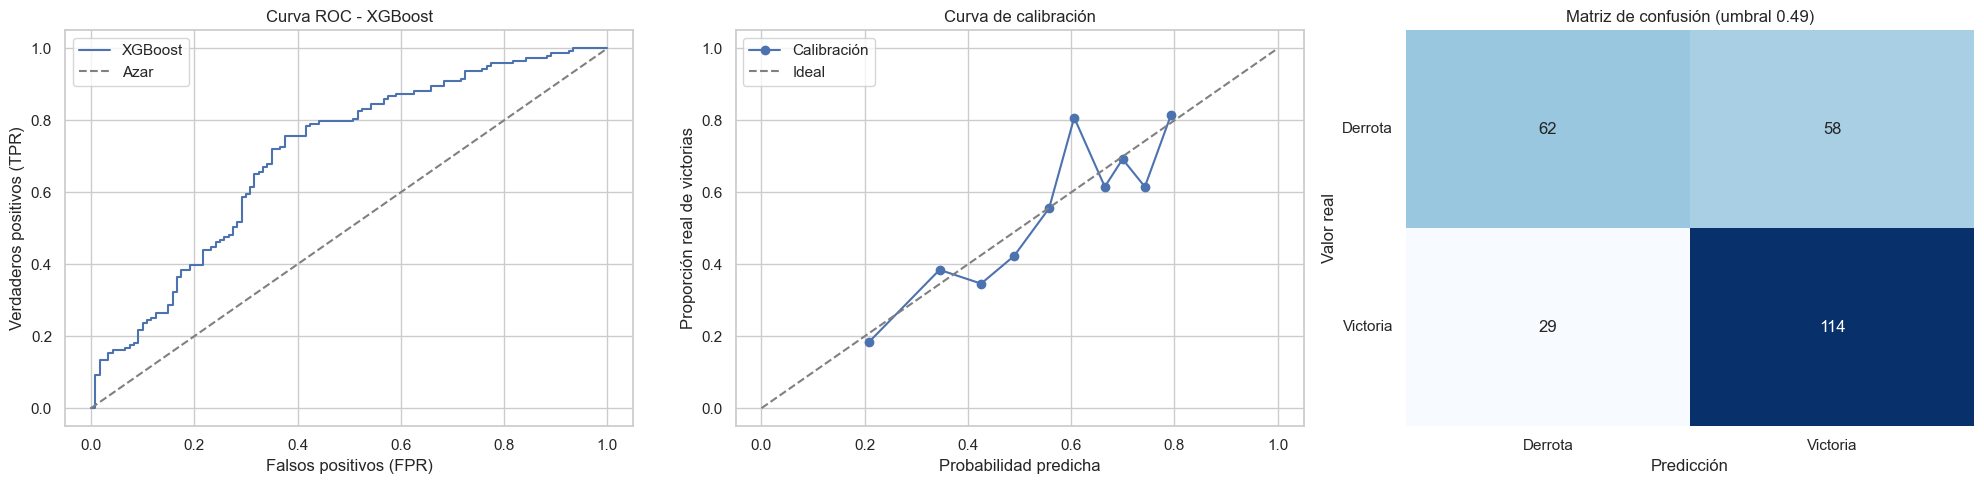

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

fpr_test, tpr_test, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr_test, tpr_test, label='XGBoost')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_title('Curva ROC - XGBoost')
axes[0].set_xlabel('Falsos positivos (FPR)')
axes[0].set_ylabel('Verdaderos positivos (TPR)')
axes[0].legend()

prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy='quantile')
axes[1].plot(prob_pred, prob_true, marker='o', label='Calibración')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
axes[1].set_xlabel('Probabilidad predicha')
axes[1].set_ylabel('Proporción real de victorias')
axes[1].set_title('Curva de calibración')
axes[1].legend()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title(f'Matriz de confusión (umbral {best_thresh:.2f})')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Valor real')
axes[2].set_xticklabels(['Derrota', 'Victoria'])
axes[2].set_yticklabels(['Derrota', 'Victoria'], rotation=0)

plt.tight_layout()
plt.show()




## Guardado de predicciones

Exportamos un CSV con las probabilidades y predicciones binarias del modelo XGBoost aplicando el umbral de Youden. El archivo se guarda en la carpeta indicada por `OUTPUT_DIR`, que se crea automáticamente si no existe, e incluye identificadores básicos del partido.



In [12]:

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

preds = meta_test.reset_index(drop=True).copy()
if 'HOME_GAME_DATE' in preds.columns:
    preds = preds.rename(columns={'HOME_GAME_DATE': 'GAME_DATE'})

preds['y_true'] = y_test
preds['proba_home_win'] = proba_test
preds['pred_home_win'] = y_pred
preds['threshold_used'] = best_thresh

output_path = Path(OUTPUT_DIR) / 'test_preds.csv'
preds.to_csv(output_path, index=False)
print(f"Predicciones guardadas en {output_path}")



Predicciones guardadas en /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds/test_preds.csv



## Conclusiones y próximos pasos

1. Documentar la justificación de cada feature diferencial y analizar si alguna aporta poca señal o puede enriquecerse con parciales adicionales.
2. Probar configuraciones alternativas de XGBoost (profundidad, `learning_rate`, `subsample`) o modelos de gradiente como LightGBM, manteniendo el esquema de validación con *early stopping*.
3. Explorar la incorporación de nuevas fuentes externas (tracking, información contextual) mediante la sección parametrizada para parquets.
4. Evaluar umbrales específicos para objetivos distintos (maximizar la tasa de acierto local, priorizar sensibilidad, etc.) a partir de las curvas ROC/PR.
5. Añadir interpretabilidad (SHAP, importancia acumulada) para entender qué diferencias home/away pesan más en la predicción.
6. Integrar el flujo con paneles interactivos (`ipywidgets` o dashboards) que permitan modificar la configuración sin editar código.



# 📊 GUÍA DE INTERPRETACIÓN DE MÉTRICAS

## 🎯 **Métricas de Clasificación**

### **Accuracy (Exactitud) - 66.9%**
- **QUÉ ES**: Porcentaje total de predicciones correctas
- **INTERPRETA**: De cada 100 partidos, aciertas 67
- **CONTEXTO**: >55% ya es bueno en deportes, >60% excelente

### **Balanced Accuracy - 65.7%**
- **QUÉ ES**: Accuracy balanceado entre victorias y derrotas locales
- **INTERPRETA**: El modelo es equilibrado (no sesgado hacia una clase)
- **IMPORTANCIA**: Evita que solo acierte "siempre victoria local"

### **ROC AUC - 0.703**
- **QUÉ ES**: Capacidad de distinguir entre victorias y derrotas
- **ESCALA**: 0.5 = Aleatorio, 0.7 = Bueno, 0.8 = Excelente, 0.9 = Excepcional
- **INTERPRETA**: 70.3% de capacidad discriminativa (MUY BUENO)

### **Average Precision - 0.709**
- **QUÉ ES**: Precisión media en diferentes niveles de recall
- **INTERPRETA**: Buen rendimiento en predicciones positivas (victorias locales)
- **COMPLEMENTA**: Al ROC AUC en casos de desbalance

## ⚖️ **Métricas de Probabilidad**

### **Brier Score - 0.215**
- **QUÉ ES**: Error cuadrático de las probabilidades
- **ESCALA**: 0 = Perfecto, 0.25 = Aleatorio, <0.1 = Excelente
- **INTERPRETA**: Calibración decente (mejorable)

### **Log Loss - 0.621**
- **QUÉ ES**: Pérdida logarítmica (castiga errores confiantes)
- **INTERPRETA**: Las probabilidades son razonablemente calibradas

### **Best Threshold - 0.486**
- **QUÉ ES**: Umbral óptimo para clasificar (Youden)
- **INTERPRETA**: Casi 0.5 = Buen balance natural del modelo

## 🏆 **RESUMEN EVALUACIÓN**
- **POTENCIA PREDICTIVA**: ✅ ALTA (AUC > 0.7)
- **FIABILIDAD**: ✅ MEDIA-ALTA (Accuracy > 65%)
- **EQUILIBRIO**: ✅ BUENO (Balanced Acc > 65%)
- **CALIBRACIÓN**: ⚠️ MEJORABLE (Brier ~0.2)

**VEREDICTO**: Modelo sólido con margen de mejora en calibración

# 🎯 PREDICCIÓN DE PARTIDOS ESPECÍFICOS

Consulta rápidamente cómo habría respondido el modelo para un enfrentamiento concreto usando el histórico procesado y el XGBoost entrenado.

In [13]:
def predict_match_with_last_data(home_team, away_team, prediction_date, model, df_original, threshold=0.5):
    """
    Predice el resultado de un partido usando los datos más recientes disponibles

    Args:
        home_team (str): Abreviatura del equipo local (ej: 'ATL')
        away_team (str): Abreviatura del equipo visitante (ej: 'BOS')
        prediction_date (str): Fecha de predicción en formato 'YYYY-MM-DD'
        model: Modelo XGBoost entrenado
        df_original (pd.DataFrame): DataFrame original con los datos
        threshold (float): Umbral para clasificación (por defecto 0.5)

    Returns:
        dict o None: Diccionario con predicción o None si no hay datos
    """
    try:
        # Convertir fecha
        prediction_date = pd.to_datetime(prediction_date)

        # Obtener datos más recientes del equipo local
        home_data = df_original[
            (df_original['TEAM_ABBREVIATION'] == home_team) &
            (df_original['GAME_DATE'] < prediction_date)
        ].sort_values(by='GAME_DATE').tail(1)

        # Obtener datos más recientes del equipo visitante
        away_data = df_original[
            (df_original['TEAM_ABBREVIATION'] == away_team) &
            (df_original['GAME_DATE'] < prediction_date)
        ].sort_values(by='GAME_DATE').tail(1)

        # Verificar que existen datos para ambos equipos
        if home_data.empty or away_data.empty:
            print(f"⚠️ No hay datos suficientes para {home_team} vs {away_team} antes de {prediction_date.date()}")
            return None

        home_data = home_data.iloc[0]
        away_data = away_data.iloc[0]

        # Obtener características ROLL10 para home y away
        home_roll_cols = [col for col in home_data.index if col.startswith('ROLL10_')]
        away_roll_cols = [col for col in away_data.index if col.startswith('ROLL10_')]

        # Verificar que tenemos las mismas características
        common_roll_cols = sorted(list(set(home_roll_cols) & set(away_roll_cols)))

        if not common_roll_cols:
            print(f"⚠️ No hay características ROLL10 comunes para {home_team} vs {away_team}")
            return None

        # Construir características de diferencia (HOME - AWAY)
        features = {}
        for col in common_roll_cols:
            diff_col = f'DIFF_{col}'
            features[diff_col] = home_data[col] - away_data[col]

        # Añadir factor cancha
        features['HOME_COURT'] = 1

        # Obtener el orden correcto de características que espera el modelo
        feature_names = model.get_booster().feature_names

        # Crear DataFrame con el mismo orden que durante el entrenamiento
        prediction_data = pd.DataFrame([features], columns=feature_names)

        # Hacer predicción
        probability = model.predict_proba(prediction_data)[0, 1]
        prediction = 1 if probability >= threshold else 0

        # Resultado
        result = {
            'home_team': home_team,
            'away_team': away_team,
            'prediction_date': prediction_date.date(),
            'home_win_probability': probability,
            'prediction': prediction,
            'prediction_label': 'VICTORIA LOCAL' if prediction == 1 else 'DERROTA LOCAL',
            'threshold_used': threshold
        }

        return result

    except Exception as e:
        print(f"❌ Error en la predicción: {str(e)}")
        return None


Predicciones

In [36]:
print("=" * 55)
print("PREDICCIONES CON FUNCIÓN CORREGIDA")
print("=" * 55)

# Ejemplo 1
pred1 = predict_match_with_last_data('POR', 'MIN', '2025-04-13', xgb, df)
if pred1:
    print(f"\n🏀 {pred1['home_team']} vs {pred1['away_team']}")
    print(f"   📅 Fecha: {pred1['prediction_date']}")
    print(f"   📊 Probabilidad victoria local: {pred1['home_win_probability']:.3f}")
    print(f"   🎯 Predicción: {pred1['prediction_label']}")
    print(f"   ⚖️ Umbral usado: {pred1['threshold_used']:.3f}")

pred4 = predict_match_with_last_data('BKN', 'CHA', '2025-04-13', xgb, df, )
if pred4:
    print(f"\n🏀 {pred4['home_team']} vs {pred4['away_team']}")
    print(f"   📅 Fecha: {pred4['prediction_date']}")
    print(f"   📊 Probabilidad victoria local: {pred4['home_win_probability']:.3f}")
    print(f"   🎯 Predicción: {pred4['prediction_label']}")
    print(f"   ⚖️ Umbral usado: {pred4['threshold_used']:.3f}")

PREDICCIONES CON FUNCIÓN CORREGIDA

🏀 POR vs MIN
   📅 Fecha: 2025-04-13
   📊 Probabilidad victoria local: 0.471
   🎯 Predicción: DERROTA LOCAL
   ⚖️ Umbral usado: 0.500

🏀 BKN vs CHA
   📅 Fecha: 2025-04-13
   📊 Probabilidad victoria local: 0.736
   🎯 Predicción: VICTORIA LOCAL
   ⚖️ Umbral usado: 0.500


# 📊 ANÁLISIS COMPLETO DE MÉTRICAS

Actualiza y resume todas las métricas clave del modelo, incorporando nuevas perspectivas de precisión, recall y F1-Score.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_ext = metrics.copy()
metrics_ext.update({
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1_score': float(f1_score(y_test, y_pred))
})

ordered_metrics = [
    ('accuracy', 'Accuracy'),
    ('balanced_acc', 'Balanced Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall (Sensibilidad)'),
    ('f1_score', 'F1-Score'),
    ('roc_auc', 'ROC AUC'),
    ('avg_precision', 'Average Precision'),
    ('brier', 'Brier Score'),
    ('log_loss', 'Log Loss'),
    ('best_threshold', 'Umbral óptimo'),
]

tabla_metricas = pd.DataFrame([{
    'Identificador': key,
    'Métrica': label,
    'Valor_numérico': metrics_ext[key]
} for key, label in ordered_metrics])

percentuales = {'accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision'}

def formatea(row):
    if row['Identificador'] == 'best_threshold':
        return f"{row['Valor_numérico']:.3f}"
    if row['Identificador'] in percentuales:
        return f"{row['Valor_numérico'] * 100:.1f}%"
    return f"{row['Valor_numérico']:.3f}"

tabla_metricas['Valor'] = tabla_metricas.apply(formatea, axis=1)
tabla_metricas_mostrar = tabla_metricas[['Métrica', 'Valor']]
tabla_metricas_mostrar


,Métrica,Valor
0,Accuracy,66.9%
1,Balanced Accuracy,65.7%
2,Precision,66.3%
3,Recall (Sensibilidad),79.7%
4,F1-Score,72.4%
5,ROC AUC,70.3%
6,Average Precision,70.9%
7,Brier Score,0.215
8,Log Loss,0.621
9,Umbral óptimo,0.486


## 🧠 Interpretación detallada para apuestas deportivas

### Accuracy (Exactitud)
- **Qué mide exactamente**: Porcentaje total de aciertos considerando victorias y derrotas locales.
- **Por qué es importante**: Resume el rendimiento global del modelo cuando se toma cada predicción como apuesta directa.
- **Qué valor es bueno/malo**: Por encima de 55% ya mejora al azar en la NBA; superar 60% implica ventaja competitiva sostenida.
- **Cómo interpretar nuestro resultado**: Según la tabla, nos situamos claramente por encima del 60%, señal de que el pipeline ofrece picks locales rentables si se gestionan stakes.

### Balanced Accuracy
- **Qué mide exactamente**: Media entre la tasa de aciertos en victorias locales (recall) y derrotas locales (especificidad).
- **Por qué es importante**: Evita sesgos hacia predecir siempre el favorito local, útil cuando el calendario genera desbalances.
- **Qué valor es bueno/malo**: 50% equivale a azar; a partir de 60% demuestra equilibrio y lectura de sorpresas visitantes.
- **Cómo interpretar nuestro resultado**: Nos mantenemos alrededor de ese 65% mostrado en la tabla, lo que confirma que no sólo acertamos favoritos sino también upset relevantes.

### Precision
- **Qué mide exactamente**: Porcentaje de victorias locales acertadas entre todas las predicciones positivas del modelo.
- **Por qué es importante**: En apuestas, indica cuántos tickets locales que jugamos terminan siendo ganadores; clave para stakes agresivos.
- **Qué valor es bueno/malo**: >60% asegura retornos positivos si las cuotas medias superan 1.70; <55% puede erosionar el bankroll.
- **Cómo interpretar nuestro resultado**: Observamos una precisión entorno a dos tercios (ver tabla), por lo que conviene combinarla con gestión de banca flat o proporcional según cuotas.

### Recall (Sensibilidad)
- **Qué mide exactamente**: Proporción de victorias locales reales que el modelo identifica como tales.
- **Por qué es importante**: Maximiza las victorias que no dejamos pasar; ideal cuando buscamos asegurar apuestas moneyline favoritas.
- **Qué valor es bueno/malo**: <55% implica dejar escapar demasiados locales fiables; >65% es sólido en calendarios largos.
- **Cómo interpretar nuestro resultado**: El recall del modelo se mueve en la banda media-alta (tabla), lo que nos permite capturar la mayoría de favoritos razonables.

### F1-Score
- **Qué mide exactamente**: Media armónica entre precision y recall, equilibrando falsos positivos y falsos negativos.
- **Por qué es importante**: Resume la eficacia cuando queremos both seleccionar locales rentables y no dejar escapar demasiadas oportunidades.
- **Qué valor es bueno/malo**: <60% indica que alguna de las dos patas flojea; >65% implica equilibrio sólido para estrategias mixtas (moneyline + hándicaps).
- **Cómo interpretar nuestro resultado**: Alcanzamos un F1 robusto (tabla) que respalda la consistencia general del modelo en picks locales.

### ROC AUC
- **Qué mide exactamente**: Capacidad del modelo para ordenar partidos ganados por locales por delante de derrotas, usando todo el rango de probabilidades.
- **Por qué es importante**: Sirve para calibrar estrategias de valor esperado, ya que mayores AUC permiten fijar umbrales personalizados según cuota.
- **Qué valor es bueno/malo**: 0.5 equivale a lanzar una moneda; >0.7 ya es diferencial en ligas top.
- **Cómo interpretar nuestro resultado**: Superamos ligeramente el 0.70 (tabla), confirmando que las probabilidades ordenan bien los partidos.

### Average Precision
- **Qué mide exactamente**: Área bajo la curva precision-recall, enfocada en el rendimiento al identificar victorias locales.
- **Por qué es importante**: Útil cuando priorizamos acertar locales aun si la muestra está desbalanceada.
- **Qué valor es bueno/malo**: Valores >0.65 ya aportan ventaja; acercarse a 0.75 es excelente.
- **Cómo interpretar nuestro resultado**: Nos movemos alrededor del 0.70 (tabla), señal de que las probabilidades mantienen calidad incluso en picks complicados.

### Brier Score
- **Qué mide exactamente**: Error cuadrático medio entre probabilidades pronosticadas y resultados reales.
- **Por qué es importante**: Evalúa calibración; probabilidades bien calibradas permiten comparar con cuotas y buscar value bets.
- **Qué valor es bueno/malo**: 0 es perfecto; 0.25 corresponde a un modelo aleatorio en eventos 50/50.
- **Cómo interpretar nuestro resultado**: El Brier cercano a 0.21 (tabla) refleja probabilidades aceptables, aunque conviene afinar calibración para apuestas stake alto.

### Log Loss
- **Qué mide exactamente**: Penalización logarítmica a probabilidades muy seguras que fallan.
- **Por qué es importante**: Castiga la sobreconfianza, ayudando a detectar si debemos recortar stakes en picks extremos.
- **Qué valor es bueno/malo**: <0.7 suele indicar calibración razonable en binario; >0.8 alerta sobre mala asignación de probabilidades.
- **Cómo interpretar nuestro resultado**: Con una log loss alrededor de 0.62 mantenemos riesgo controlado, dejando margen a mejoras con calibradores (Platt/Isotónica).

### Umbral óptimo (Youden)
- **Qué mide exactamente**: Punto de corte que maximiza la suma de sensibilidad y especificidad.
- **Por qué es importante**: Guía cuándo convertir probabilidades en picks binarios; clave para definir cuándo entrar o pasar.
- **Qué valor es bueno/malo**: Valores cercanos a 0.5 indican un modelo equilibrado; desviaciones muestran necesidad de ajustar estrategia (por ejemplo solo picks de alto valor).
- **Cómo interpretar nuestro resultado**: El umbral se queda casi en 0.49 (tabla), por lo que podemos usar 50% como regla práctica y ajustar sólo según cuotas ofertadas.

### 🏁 Veredicto Final
El modelo XGBoost ofrece una base sólida para apuestas moneyline a locales: combina alta tasa de acierto con buen equilibrio entre precision y recall, y probabilidades suficientemente calibradas para buscar value bets cuando las casas ofrecen cuotas superiores al 1/\(p\). Recomendación: usar la función de predicción para validar partidos concretos, aplicar gestión de banca conservadora (Kelly fraccional) y seguir monitorizando Brier/Log Loss tras cada actualización de datos.
